In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(np.__version__)

1.26.4


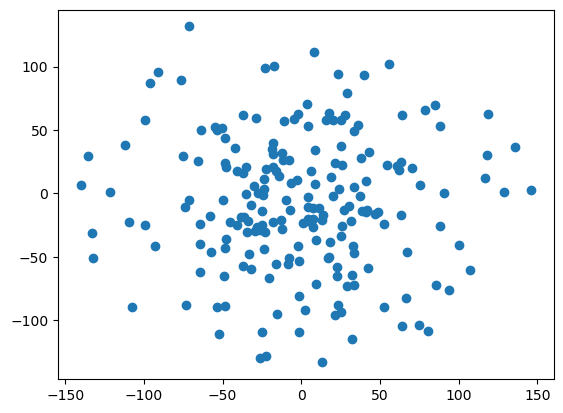

In [2]:
from utils import create_dopant_configuration

R = 150
n_a = 200
save_dir = "/home/hd/hd_hd/hd_gy283/kmc_project/configs"
_ = create_dopant_configuration(radius=R, n_a=n_a, n_d=3, name_a="robustness_acc", name_d="robustness_don", mode="mixed", eps=0.8, save_dir=save_dir)

acc_pos = np.loadtxt(f"{save_dir}/robustness_acc.txt")
plt.scatter(*acc_pos.T)

[ 77 123  81  89 147 103 193 167 131  18 182 134  41  73 142  65 152 188
 118 154 177  29  50 192 185 196 114  31 162 138  62  48 180 112 108  37
  35 183   1  76 184 159  51  52  21  36  42   6 199  71  72 136  75  64
 106 135 195  11  55 128  91  56 117 191  66 120 107  10 161 137 121 145
 174 144  30  58 194  59 122 175  34  97  45 129 150 171 141   0 146 165
 153 172  53   3  74  88  57  69 151 110]
(200, 2)
(200, 2)


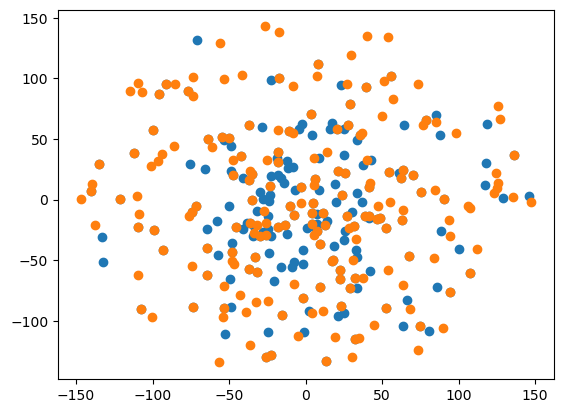

In [37]:
acc_pos = np.loadtxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/configs/robustness_acc.txt")

n_rand = 100

new_pos = acc_pos.copy()

acc_indices = np.random.choice(n_a, size=n_rand, replace=False)
print(acc_indices)

for idx in acc_indices:
    radius = R * np.sqrt(np.random.uniform(0.0, 1.0))
    phi = np.random.uniform(0.0, 2*np.pi)
    x = radius*np.cos(phi)
    y = radius*np.sin(phi)

    new_pos[idx] = np.array([x, y])
print(new_pos.shape)
print(acc_pos.shape)
plt.scatter(*acc_pos.T)
plt.scatter(*new_pos.T)

np.savetxt(f"{save_dir}/robustness_acc_nrand={n_rand}.txt", new_pos, fmt="%.6f", delimiter="\t")

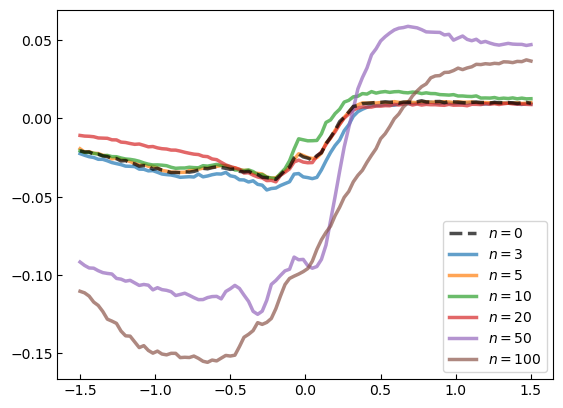

In [2]:
ROOT = Path("/home/hd/hd_hd/hd_gy283/kmc_project")
WS_DIR = Path("/gpfs/bwfor/work/ws/hd_gy283-my_data")
BINARY = ROOT / "build" / "kmc_project"
SH_SCRIPT = ROOT / "scripts" / "slurm" / "single_curve.sh"

nrands = [0, 3, 5, 10, 20, 50, 100]

x = np.linspace(-1.5, 1.5, 100)

for i in nrands:
    changed_pos = np.load(f"{WS_DIR}/robustness_acceptor_changes/acc_changed_nrand={i}.npz")
    if i == 0:
        plt.plot(x, changed_pos["current"], alpha=.7, lw=2.5, c="k", linestyle="dashed", label=f"$n={i}$", zorder=3)
    else:
        plt.plot(x, changed_pos["current"], alpha=.7, label=f"$n={i}$", lw=2.5)
    plt.tick_params(which="major", direction="in")

plt.legend()

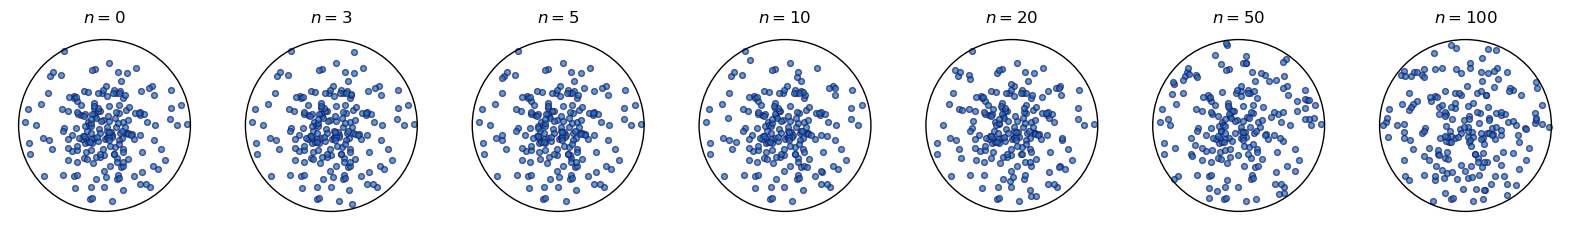

In [56]:
import matplotlib.patches as ps

fig, ax = plt.subplots(nrows=1, ncols=len(nrands), figsize=(20, 20))
plot_kwargs = {
    "s": 17.5,
    "alpha": .7,
    "edgecolor": "midnightblue"
}
circle_kwargs = {
    "xy": (0.0, 0.0),
    "radius": R + 2.5,
    "fill": None
}
for i, nrand in enumerate(nrands):
    positions = np.loadtxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/configs/robustness_acc_nrand={nrand}.txt")
    ax[i].scatter(*positions.T, **plot_kwargs)
    ax[i].set_aspect("equal")
    ax[i].set_title(f"$n={nrand}$")
    ax[i].add_patch(ps.Circle(**circle_kwargs))
    ax[i].spines[["top", "bottom", "right", "left"]].set_visible(False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    